# PCA 降维：找数据最「伸展」的方向

**课程 0012 配套练习** · 内核：`deeplearning`

前置：课程 0011（无监督）+ 线性代数基础。PCA 是**无监督降维**：找出几个互相垂直、方差递减的新方向，把数据投影过去，用更少维度保留大部分信息。这是经典算法系列最后一课。

> 读完后请回答：为什么「方差最大的方向」就是「信息最多的方向」？

方差大意味着信息能被很好的分开(分散)，如果降维后方差小说明没有很好的分开数据

## 直觉：椭圆里的主方向

先造一坨「斜的椭圆」数据，PCA 的主轴一眼就能看出来——PC1 沿长轴、PC2 沿短轴。

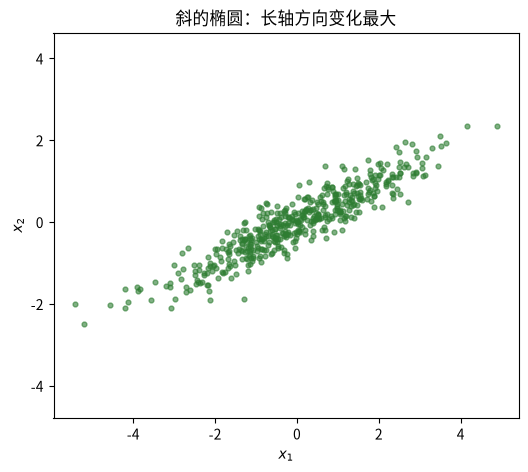

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# matplotlib 中文字体
import matplotlib as mpl
from matplotlib import font_manager
for name in ["Noto Sans CJK SC", "Noto Serif CJK SC", "WenQuanYi Zen Hei", "SimHei"]:
    if any(f.name == name for f in font_manager.fontManager.ttflist):
        mpl.rcParams["font.sans-serif"] = [name]
        break
mpl.rcParams["axes.unicode_minus"] = False

rng = np.random.default_rng(0)
base = rng.normal(size=(500, 2))
Xe = base @ np.array([[1.5, 0.6], [0.6, 0.6]])    # 旋转+拉伸 → 斜椭圆
# 矩阵非对角元 0.6 不为 0，代表两个变量正相关，等高线椭圆发生旋转；特征值 1.8 与 0.3 差距很大，说明长短轴差异大，椭圆被强烈拉伸。
Xe = Xe - Xe.mean(0)

plt.figure(figsize=(6, 5))
plt.scatter(Xe[:, 0], Xe[:, 1], s=12, alpha=0.6, color="#2e7d32")
plt.axis("equal"); plt.xlabel("$x_1$"); plt.ylabel("$x_2$")
plt.title("斜的椭圆：长轴方向变化最大")
plt.show()

## 手写 PCA：四步

中心化 → 协方差矩阵 → 特征值分解 → 取前 k 个特征向量投影。特征值 λ 就是该主轴上的方差。

特征值（=各主轴方差）： [3.141 0.085]
解释方差比： [0.974 0.026]  合计: 1.0


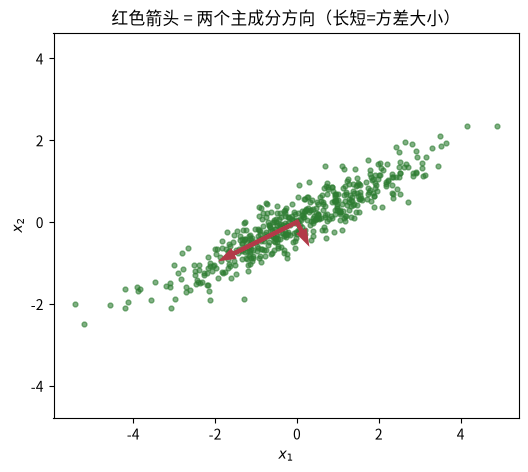

In [ ]:
def pca_fit(X, k=2):
    """手写 PCA。返回 (Z投影, 特征值, 特征向量, 解释方差比)。"""
    Xc = X - X.mean(axis=0)                                # ① 中心化
    cov = (Xc.T @ Xc) / (len(X) - 1)                       # ② 协方差矩阵
    eigvals, eigvecs = np.linalg.eigh(cov)                 # ③ 特征值分解
    order = np.argsort(eigvals)[::-1]                      # 按特征值降序   # Returns the indices that would sort an array.
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]    # 排序后的特征值和特征向量
    Z = Xc @ eigvecs[:, :k]                                # ④ 投影, Xc:(n_samples, n_features), eigvecs[:, :k]:(n_features, k) → Z:(n_samples, k)
    ratio = eigvals / eigvals.sum()                        # 解释方差比
    return Z, eigvals, eigvecs, ratio

Z, ev, evec, ratio = pca_fit(Xe, k=2)
print("特征值（=各主轴方差）：", np.round(ev, 3))
print("解释方差比：", np.round(ratio, 3), " 合计:", round(float(ratio.sum()), 3))

# 把主轴画上去（PC1 方向 = evec[:, 0]）
scale = np.sqrt(ev)                                        # 长度按方差开根
plt.figure(figsize=(6, 5))
plt.scatter(Xe[:, 0], Xe[:, 1], s=12, alpha=0.6, color="#2e7d32")
for i in range(2):
    plt.arrow(0, 0, evec[0, i] * scale[i], evec[1, i] * scale[i],
              color="#b23a48", lw=3, head_width=0.15)
plt.axis("equal"); plt.xlabel("$x_1$"); plt.ylabel("$x_2$")
plt.title("红色箭头 = 两个主成分方向（长短=方差大小）")
plt.show()

## 验证：手写 vs sklearn 完全一致

用鸢尾花（4 特征）验证——这是标准教材数据集，特征值、解释方差比、投影都应和 sklearn 一致（主轴可能差个正负号）。

In [3]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

iris = load_iris()
X = StandardScaler().fit_transform(iris.data)     # 注意：先标准化！
y = iris.target

Z_hand, ev_hand, evec_hand, ratio_hand = pca_fit(X, k=2)
pca = PCA(n_components=2).fit_transform(X)

print("手写解释方差比：", np.round(ratio_hand[:2], 3))
print("sklearn 解释方差比：", np.round(PCA().fit(X).explained_variance_ratio_[:2], 3))

# 符号对齐后比较投影
for i in range(2):
    if np.corrcoef(Z_hand[:, i], pca[:, i])[0, 1] < 0:
        Z_hand[:, i] *= -1
print("手写与 sklearn 投影一致：", np.allclose(Z_hand, pca))

手写解释方差比： [0.73  0.229]
sklearn 解释方差比： [0.73  0.229]
手写与 sklearn 投影一致： True


## 碎石图：决定保留几维

把特征值从大到小画出来：前几个陡、后面平。累计解释方差 ≥ 80%（通常 2 维即可）就是保留维数。鸢尾花前 2 维解释约 96%。

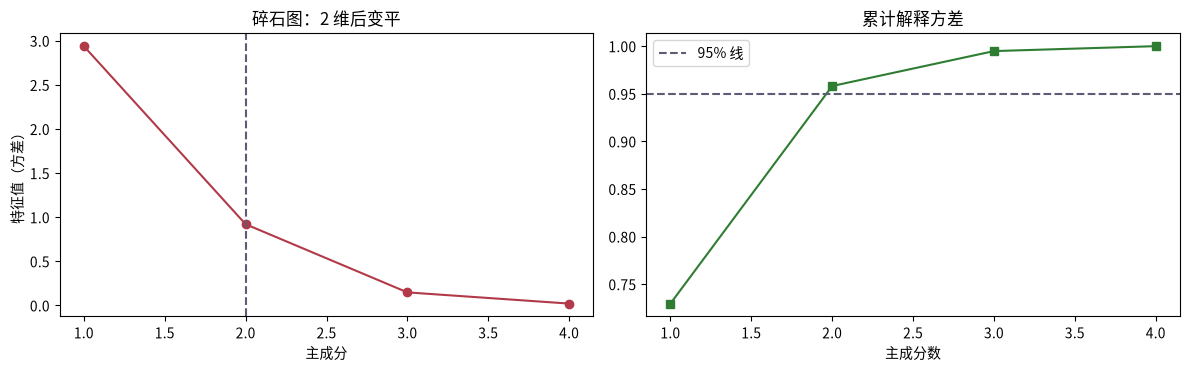

In [4]:
ev_all = PCA().fit(X).explained_variance_
cum = np.cumsum(PCA().fit(X).explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].plot(range(1, 5), ev_all, "o-", color="#b23a48")
axes[0].axvline(2, ls="--", color="#5c5c75"); axes[0].set_title("碎石图：2 维后变平")
axes[0].set_xlabel("主成分"); axes[0].set_ylabel("特征值（方差）")
axes[1].plot(range(1, 5), cum, "s-", color="#2e7d32")
axes[1].axhline(0.95, ls="--", color="#5c5c75", label="95% 线")
axes[1].set_title("累计解释方差"); axes[1].set_xlabel("主成分数"); axes[1].legend()
plt.tight_layout(); plt.show()

## 降维后的 2D 可视化

把 4 维鸢尾花投到 PC1-PC2 平面，三类依然可分——说明 2 维确实保留了分类所需的信息。

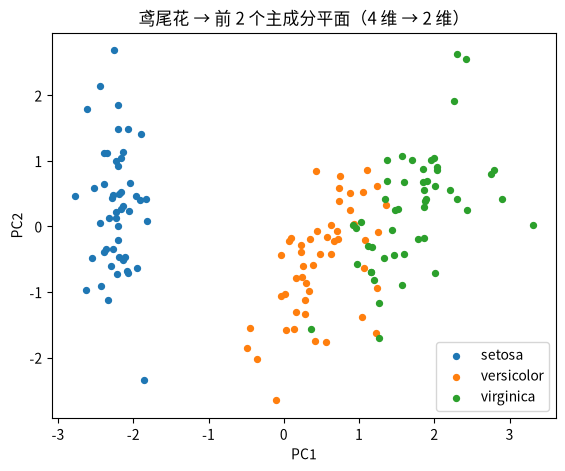

In [5]:
plt.figure(figsize=(6.5, 5))
for c, name in enumerate(iris.target_names):
    plt.scatter(pca[y == c, 0], pca[y == c, 1], s=18, label=name)
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.legend()
plt.title("鸢尾花 → 前 2 个主成分平面（4 维 → 2 维）")
plt.show()

## 练习（S 理解 / M 动手 / H 挑战）

**S1.** 为什么「方差最大的方向」就是「信息最多的方向」？如果所有点挤在一根线上（一个特征 = 另一个特征的线性组合），数据其实是几维的？PCA 会给出什么特征值？

**S2.** 主成分必须互相正交，为什么？如果 PC2 和 PC1 有重叠成分，会出什么问题？

**M1.** 手写 `pca_fit` 的 k 参数：把鸢尾花降到 1 维、2 维、3 维，分别打印累计解释方差比。要解释 95% 的方差，最少需要几维？

**M2.** 不标准化直接对原始鸢尾花数据（sepal/petal 的厘米值）做 PCA，看第一主成分被哪个特征主导（检查 `evec[:, 0]` 的系数）。再对比标准化版，说明为什么量纲会霸占方差。

**H1.** 用交叉验证对比「全 4 维」vs「PCA 2 维」在逻辑回归上的准确率。PCA 掉了多少？在真实场景里，你会为了什么目的接受这个损失？（可视化、去相关、降维加速、去噪）

**H2.** 面试题：PCA 和 SVD 的关系？为什么实际实现常用 SVD 而不是直接算协方差矩阵特征分解？（提示：数值稳定性、避免显式构造协方差）。

In [ ]:
# pass  # 练习区（S1/S2）
# 方差衡量样本离散程度，方差大样本区分度高，携带更多信息；样本全部落在一条直线，数据实际为 1 维；PCA 会得到一个非零特征值，一个等于 0 的特征值。

# 主成分正交保证各主成分互不相关，信息不重复；若不正交，主成分存在信息冗余，方差被重复统计，无法正确提取剩余方向的最大方差。

In [ ]:
# pass  # 练习区（M1/M2）
# 解释方差比=特征值/特征值总和，累计解释方差比=前 k 个特征值/特征值总和。

# PCA 对特征尺度极度敏感；量纲大的特征会霸占方差，主导主成分。不同单位的特征做 PCA，必须先标准化。

In [ ]:
# pass  # 练习区（H1/H2）
# PCA 降维会损失少量信息带来轻微准确率下降；为了可视化、运算加速、消除特征相关性、抑制噪声，工程上可以接受少量损失。

# 中心化数据的 PCA 等价于对数据矩阵做 SVD，右奇异向量就是主成分；SVD 不需要显式计算\(X^TX\)协方差矩阵，拥有更好的数值稳定性，因此工程实现优先使用 SVD